In [44]:
import tensorflow as tf
from tensorflow import keras

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from tensorflow.keras.models import Model
import copy
from pathlib import Path

from keras.models import Sequential, load_model, clone_model
from keras.layers import Input, Conv1D, Conv2D, AvgPool1D, MaxPooling1D, MaxPooling2D, ZeroPadding1D, BatchNormalization, Flatten, Dense, Activation, Dropout
from keras.activations import softmax
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, LearningRateScheduler
from keras.utils import get_file, to_categorical
from keras.backend import clear_session
from keras.preprocessing import image

import qualia_codegen_core
from qualia_codegen_core.graph.KerasModelGraph import KerasModelGraph
from qualia_codegen_core.graph.Quantization import Quantization
from qualia_codegen_core.graph.RoundMode import RoundMode

from importlib.resources import files

In [45]:
# Charger les données MNIST

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test :", x_test.shape)
print("y_test :", y_test.shape)

# Afficher la distribution des labels
labels, counts = np.unique(y_train, return_counts=True)
for label, count in zip(labels, counts):
    print(f"Label {label} : {count} images")

x_train: (60000, 28, 28)
y_train: (60000,)
x_test : (10000, 28, 28)
y_test : (10000,)
Label 0 : 5923 images
Label 1 : 6742 images
Label 2 : 5958 images
Label 3 : 6131 images
Label 4 : 5842 images
Label 5 : 5421 images
Label 6 : 5918 images
Label 7 : 6265 images
Label 8 : 5851 images
Label 9 : 5949 images


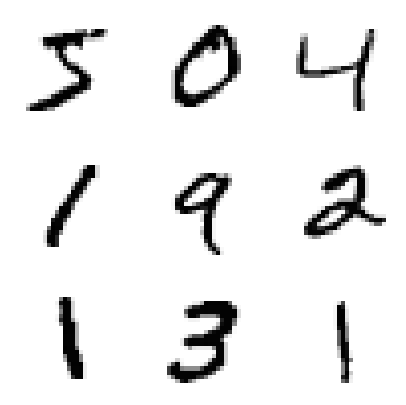

In [46]:
# Visualiser quelques chiffres

plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='Greys')
    plt.axis('off')
plt.show()

In [47]:
# Préparer les données pour le CNN

x_train = x_train.reshape(-1,28,28,1).astype('float32') / 255
x_test  = x_test.reshape(-1,28,28,1).astype('float32') / 255

input_shape = (28,28,1)

In [48]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # Couche 1 : seulement 8 filtres, stride=2 remplace le Pooling
    layers.Conv2D(8, (3, 3), strides=(2, 2), padding='same', activation='relu', input_shape=(28, 28, 1)),
    
    # Couche 2 : seulement 16 filtres, stride=2
    layers.Conv2D(16, (3, 3), strides=(2, 2), padding='same', activation='relu'),
    
    layers.Flatten(),
    # Couche dense réduite
    layers.Dense(32, activation='relu'),
    layers.Dense(10) # Sortie (Logits)
])

c:\ProgramData\anaconda3\envs\environnement_Sae_IA\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
# Entraîner le modèle
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9116 - loss: 0.2923 - val_accuracy: 0.9663 - val_loss: 0.1106
Epoch 2/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9664 - loss: 0.1084 - val_accuracy: 0.9790 - val_loss: 0.0774
Epoch 3/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9762 - loss: 0.0785 - val_accuracy: 0.9790 - val_loss: 0.0754
Epoch 4/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9794 - loss: 0.0646 - val_accuracy: 0.9838 - val_loss: 0.0650
Epoch 5/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9839 - loss: 0.0517 - val_accuracy: 0.9832 - val_loss: 0.0653
Epoch 6/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9852 - loss: 0.0450 - val_accuracy: 0.9833 - val_loss: 0.0617
Epoch 7/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9874 - loss: 0.0379 - val_accuracy: 0.9852 - val_loss: 0.0641
Epoch 8/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9894 - loss: 0.0333 - 

In [50]:
# Evoluer le modèle

score = model.evaluate(x_test, y_test, verbose=1)
print(f"Test loss    : {score[0]:.4f}")
print(f"Test accuracy: {score[1]*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9840 - loss: 0.0868
Test loss    : 0.0868
Test accuracy: 98.40%


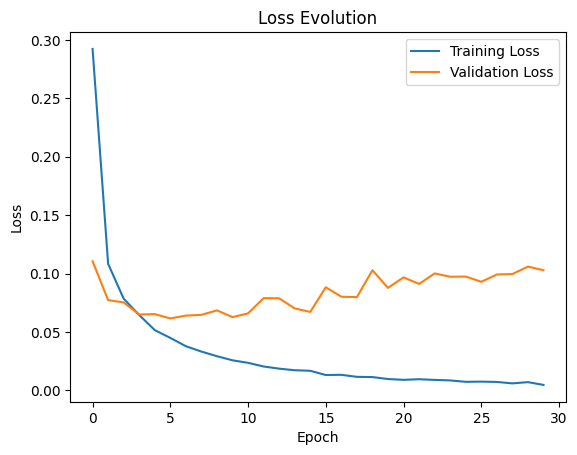

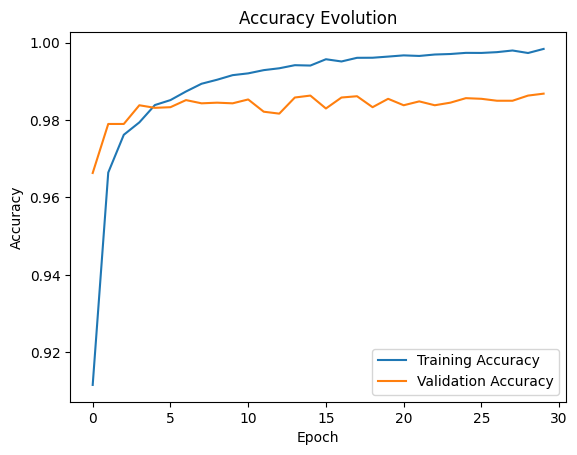

In [51]:
# Affichage

# Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Evolution')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Evolution')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.98      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.98       892
           6       0.99      0.97      0.98       958
           7       0.98      0.99      0.99      1028
           8       0.98      0.98      0.98       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



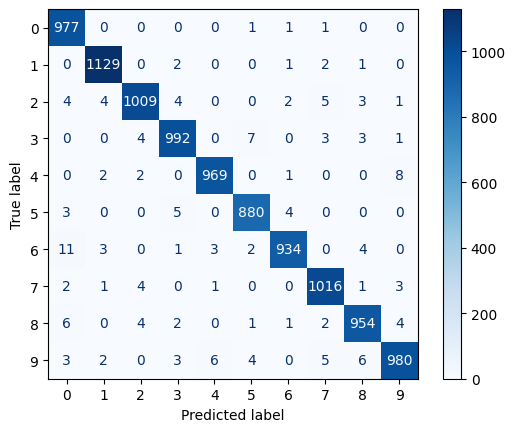

In [52]:
# Matrice de confusion et rapport de classification

y_pred = np.argmax(model.predict(x_test), axis=1)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')

# Rapport de classification
print(classification_report(y_test, y_pred))

In [53]:
model_no_softmax = Model(
    inputs=model.layers[0].input,
    outputs=model.layers[-2].output
)

In [54]:
#!pip install qualia_codegen

main_path = str((files('qualia_codegen_core.examples')/'Linux'/'main.cpp').resolve())
libqualia_neuralnetwork_path = str(files('libqualia-neuralnetwork').resolve())

In [55]:
modelgraph = KerasModelGraph(model_no_softmax).convert()
print(modelgraph)

—————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————
Inputs                                           | Layer                                            | Outputs                                          | Input shape                                      | Output shape                                    
—————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————
                                                 | input_layer_5                                    | conv2d_10                                        | (1, 28, 28, 1)                                   | ((1, 28, 28, 1),)                  

In [56]:
NUM_CLASSES=10

y_test_categorical = to_categorical(y_test, NUM_CLASSES)

np.savetxt('x_test_mnist.csv', x_test.reshape((x_test.shape[0], -1)), delimiter=',', fmt='%s')
np.savetxt('y_test_mnist.csv', y_test_categorical, delimiter=',', fmt='%s')

In [58]:
import copy
from qualia_codegen_core.graph.Quantization import Quantization
from qualia_codegen_core.graph.RoundMode import RoundMode

# 1. Copie du graphe original
int_modelgraph = copy.deepcopy(modelgraph)

# 2. Annotation (On remet 8 car 'None' nécessite des données de calibration)
for node in int_modelgraph.nodes:
    node.q = Quantization(
        number_type=int,      
        width=16,             
        long_width=32,        
        weights_scale_factor=8, 
        output_scale_factor=8,  
        weights_round_mode=RoundMode.FLOOR, 
        output_round_mode=RoundMode.FLOOR
    )

# 3. Génération du dossier (pour le test PC Host)
# Cette ligne crée le dossier ./mnist_output_int16
success = qualia_codegen_core.Converter(output_path=Path('./mnist_output_int16')).convert_model(int_modelgraph)

if success:
    print("Étape 1 : Dossier mnist_output_int16 généré avec succès !")
    
    # 4. Création du fichier .h pour le M5Stack
    # Pour obtenir le texte, on appelle le convertisseur SANS output_path
    int_res_text = qualia_codegen_core.Converter().convert_model(int_modelgraph)
    
    with open('./mnist_int16.h', 'w') as f:
        f.write(int_res_text)
    print("Étape 2 : Fichier mnist_int16.h généré avec succès !")
else:
    print("Erreur : La conversion a échoué. Vérifie les messages d'erreur au-dessus.")

Graphviz not available
Graphviz not available


Étape 1 : Dossier mnist_output_int16 généré avec succès !
Étape 2 : Fichier mnist_int16.h généré avec succès !


In [59]:
!g++ -std=c++17 -Wall -pedantic -Ofast -o mnist_int16 \
-include mnist_output_int16/include/defines.h \
-Imnist_output_int16/include \
-I{libqualia_neuralnetwork_path} \
mnist_output_int16/model.c \
mnist_output_int16/metrics.cpp \
{libqualia_neuralnetwork_path}/NeuralNetwork.cpp \
{main_path}

cc1plus.exe: fatal error: mnist_output_int16/metrics.cpp: No such file or directory
compilation terminated.
C:\ProgramData\anaconda3\envs\environnement_Sae_IA\Lib\site-packages\qualia_codegen_core\examples\Linux\main.cpp:13:10: fatal error: metrics.h: No such file or directory
   13 | #include "metrics.h"
      |          ^~~~~~~~~~~
compilation terminated.


In [60]:


# EVALUATE on FULL TEST DATASET (10 000 images)
# *********************************************
!mnist_floating x_test_mnist.csv y_test_mnist.csv

# EVALUATE on REDUCED TEST DATASET (1 000 images)
# ***********************************************
!mnist_floating x_test_mnist_1000.csv y_test_mnist_1000.csv

acc=0.9897
acc=0.989
